<Axes: >

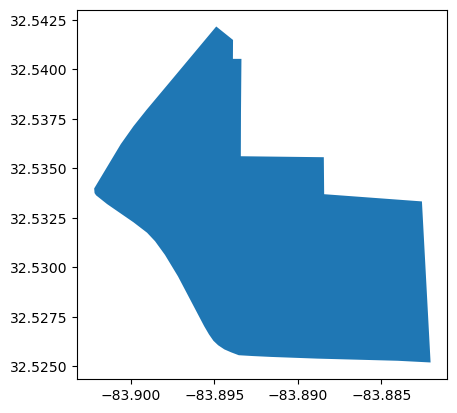

In [5]:
# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

# Look for CU Boulder using geocode_to_gdf
fvsu_gdf =osm.geocode_to_gdf("Fort Valley State University")
fvsu_gdf

# Plot the boundary
fvsu_gdf = osm.geocode_to_gdf("Fort Valley State University")
fvsu_gdf.plot()

In [9]:
# Look for everything labeled 'University' within 1000m of an address
uni = osm.features_from_address(
    'Fort Valley, Georgia, USA',
    {'amenity': ['university']},
    dist=2000) # adjust dist= to find more buildings
uni

nodes  \
element_type osmid                                                           
way          722635040   [6778464878, 6778464877, 6778464876, 677846487...   
             1018989981  [9398551937, 9398551953, 9398551956, 939855193...   

                           addr:city addr:country addr:housenumber  \
element_type osmid                                                   
way          722635040   Fort Valley           US             1005   
             1018989981          NaN          NaN              NaN   

                        addr:postcode addr:state             addr:street  \
element_type osmid                                                         
way          722635040     31030-4313         GA  State University Drive   
             1018989981           NaN        NaN                     NaN   

                            amenity  ele gnis:feature_id  \
element_type osmid                                         
way          722635040   university  161          355882   
             1018989981  university  NaN             NaN   

                                                 name  \
element_type osmid                                      
way          722635040   Fort Valley State University   
             1018989981                           NaN   

                                             operator operator:wikidata  \
element_type osmid                                                        
way          722635040   University System of Georgia          Q2495809   
             1018989981                           NaN               NaN   

                         wikidata                        wikipedia  \
element_type osmid                                                   
way          722635040   Q5472214  en:Fort Valley State University   
             1018989981       NaN                              NaN   

                                                                  geometry  
element_type osmid                                                          
way          722635040   POLYGON ((-83.89489 32.54216, -83.89389 32.541...  
             1018989981  POLYGON ((-83.89842 32.54063, -83.89714 32.541...

In [12]:
# Find University of Colorado (East Campus)
main_campus = osm.features_from_address(
    "Fort Valley State University",
    {'amenity': ['university']})

main_campus

nodes  \
element_type osmid                                                           
way          722635040   [6778464878, 6778464877, 6778464876, 677846487...   
             1018989981  [9398551937, 9398551953, 9398551956, 939855193...   

                           addr:city addr:country addr:housenumber  \
element_type osmid                                                   
way          722635040   Fort Valley           US             1005   
             1018989981          NaN          NaN              NaN   

                        addr:postcode addr:state             addr:street  \
element_type osmid                                                         
way          722635040     31030-4313         GA  State University Drive   
             1018989981           NaN        NaN                     NaN   

                            amenity  ele gnis:feature_id  \
element_type osmid                                         
way          722635040   university  161          355882   
             1018989981  university  NaN             NaN   

                                                 name  \
element_type osmid                                      
way          722635040   Fort Valley State University   
             1018989981                           NaN   

                                             operator operator:wikidata  \
element_type osmid                                                        
way          722635040   University System of Georgia          Q2495809   
             1018989981                           NaN               NaN   

                         wikidata                        wikipedia  \
element_type osmid                                                   
way          722635040   Q5472214  en:Fort Valley State University   
             1018989981       NaN                              NaN   

                                                                  geometry  
element_type osmid                                                          
way          722635040   POLYGON ((-83.89489 32.54216, -83.89389 32.541...  
             1018989981  POLYGON ((-83.89842 32.54063, -83.89714 32.541...

<Axes: >

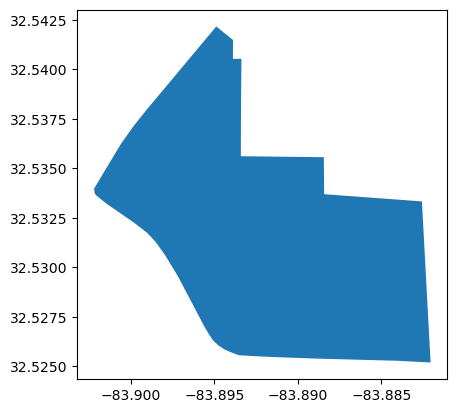

In [13]:
main_campus = main_campus[main_campus["name"] == "Fort Valley State University"]
main_campus.plot()

In [16]:
# Extract ploygon from geometry
polygon = main_campus.geometry.iloc[0]
polygon
# Get buildings with the polygon using features_from_polygon()
buildings = osm.features_from_polygon(polygon,
                                      tags={"building": True})
buildings

nodes  \
element_type osmid                                                           
way          722635002   [6778464690, 6778464689, 6778464688, 677846468...   
             722635003   [6778464694, 6778464693, 6778464692, 677846469...   
             722635004   [6778464724, 6778464723, 6778464722, 677846472...   
             817860948   [7638135391, 7638135392, 7638135393, 763813539...   
             817860949   [7638135397, 7638135398, 7638135399, 763813540...   
...                                                                    ...   
             1176271042  [10929067223, 10929067224, 10929067225, 109290...   
             1176271043  [10929067229, 10929067230, 10929067231, 109290...   
             1468103236  [13465046971, 13465046972, 13465046973, 134650...   
             1468103237  [13465046976, 13465046977, 13465046978, 134650...   
             1468103238  [13465046980, 13465046981, 13465046982, 134650...   

                            amenity    building  \
element_type osmid                                
way          722635002   restaurant  university   
             722635003      library  university   
             722635004          NaN  university   
             817860948          NaN  university   
             817860949          NaN  university   
...                             ...         ...   
             1176271042         NaN         yes   
             1176271043         NaN         yes   
             1468103236         NaN         yes   
             1468103237         NaN         yes   
             1468103238         NaN         yes   

                                                          name  \
element_type osmid                                               
way          722635002                     Food Service Center   
             722635003                   Hunt Memorial Library   
             722635004   Health and Physical Education Complex   
             817860948                    Athletic Field House   
             817860949     Academic Classroom and Lab Building   
...                                                        ...   
             1176271042                                    NaN   
             1176271043                                    NaN   
             1468103236                                    NaN   
             1468103237                                    NaN   
             1468103238                                    NaN   

                                                                  geometry  \
element_type osmid                                                           
way          722635002   POLYGON ((-83.89581 32.53823, -83.89580 32.537...   
             722635003   POLYGON ((-83.89508 32.53883, -83.89508 32.538...   
             722635004   POLYGON ((-83.89816 32.53294, -83.89812 32.533...   
             817860948   POLYGON ((-83.89562 32.53263, -83.89540 32.532...   
             817860949   POLYGON ((-83.89906 32.53580, -83.89878 32.535...   
...                                                                    ...   
             1176271042  POLYGON ((-83.88814 32.53031, -83.88814 32.530...   
             1176271043  POLYGON ((-83.89257 32.53278, -83.89271 32.532...   
             1468103236  POLYGON ((-83.88557 32.53209, -83.88557 32.531...   
             1468103237  POLYGON ((-83.88632 32.53170, -83.88632 32.531...   
             1468103238  POLYGON ((-83.88627 32.53169, -83.88628 32.531...   

                        operator:type demolished leisure complex  \
element_type osmid                                                 
way          722635002            NaN        NaN     NaN     NaN   
             722635003     university        NaN     NaN     NaN   
             722635004            NaN        NaN     NaN     NaN   
             817860948            NaN        NaN     NaN     NaN   
             817860949            NaN        NaN     NaN     NaN   
...                               ...   

<Axes: >

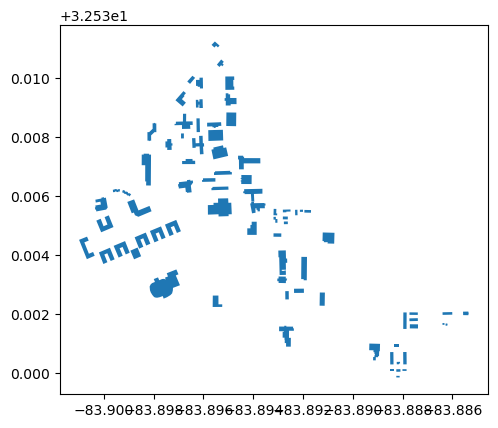

In [17]:
# Plot the buildings
buildings.plot()

In [18]:
# Get roads
roads = osm.features_from_polygon(polygon,
                                      tags={"highway": True})
roads

geometry  \
element_type osmid                                                           
node         7643723441                         POINT (-83.89513 32.54062)   
             7643723442                         POINT (-83.89512 32.53780)   
             7643723477                         POINT (-83.89804 32.53777)   
way          9424161     LINESTRING (-83.89623 32.54091, -83.89606 32.5...   
             9424481     LINESTRING (-83.89165 32.53214, -83.89164 32.5...   
...                                                                    ...   
             1378601430  LINESTRING (-83.88819 32.53128, -83.88809 32.5...   
             1378601431  LINESTRING (-83.88844 32.53087, -83.88881 32.5...   
             1378601432  LINESTRING (-83.88881 32.53087, -83.88882 32.5...   
             1378601433  LINESTRING (-83.88822 32.53219, -83.88646 32.5...   
             1482336767  LINESTRING (-83.89468 32.53610, -83.89464 32.5...   

                         bus      highway             name public_transport  \
element_type osmid                                                            
node         7643723441  yes     bus_stop  Shuttle Pick-Up         platform   
             7643723442  yes     bus_stop  Shuttle Pick-Up         platform   
             7643723477  yes     bus_stop  Shuttle Pick-Up         platform   
way          9424161     NaN      service              NaN              NaN   
             9424481     NaN  residential    Toomer Circle              NaN   
...                      ...          ...              ...              ...   
             1378601430  NaN      service              NaN              NaN   
             1378601431  NaN      service              NaN              NaN   
             1378601432  NaN      service              NaN              NaN   
             1378601433  NaN      service              NaN              NaN   
             1482336767  NaN      footway              NaN              NaN   

                        access  \
element_type osmid               
node         7643723441    NaN   
             7643723442    NaN   
             7643723477    NaN   
way          9424161       NaN   
             9424481       NaN   
...                        ...   
             1378601430    NaN   
             1378601431    NaN   
             1378601432    NaN   
             1378601433    NaN   
             1482336767    NaN   

                                                                     nodes  \
element_type osmid                                                           
node         7643723441                                                NaN   
             7643723442                                                NaN   
             7643723477                                                NaN   
way          9424161     [71882237, 71882236, 71882233, 6778464828, 677...   
             9424481     [71892601, 71884473, 71884475, 71884479, 71884...   
...                                                                    ...   
             1378601430  [71892605, 12765673687, 12765673688, 127656736...   
             1378601431  [12765673694, 12765673699, 12765673700, 127657...   
             1378601432                         [12765673699, 12765710712]   
             1378601433  [12765710713, 12765710714, 12765710715, 127657...   
             1482336767              [13593874097, 7643782940, 7638305535]   

                        oneway  surface tiger:cfcc  ... tiger:name_type  \
element_type osmid                                  ...                   
node         7643723441    NaN      NaN        NaN  ...             NaN   
             7643723442    NaN      NaN        NaN  ...             NaN   
             7643723477    NaN      NaN        NaN  ...             NaN   
way          9424161       yes  asphalt        NaN  ...             NaN   
             9424481       NaN      NaN        A41  ...             Cir   
...                        ...      ... 

<Axes: >

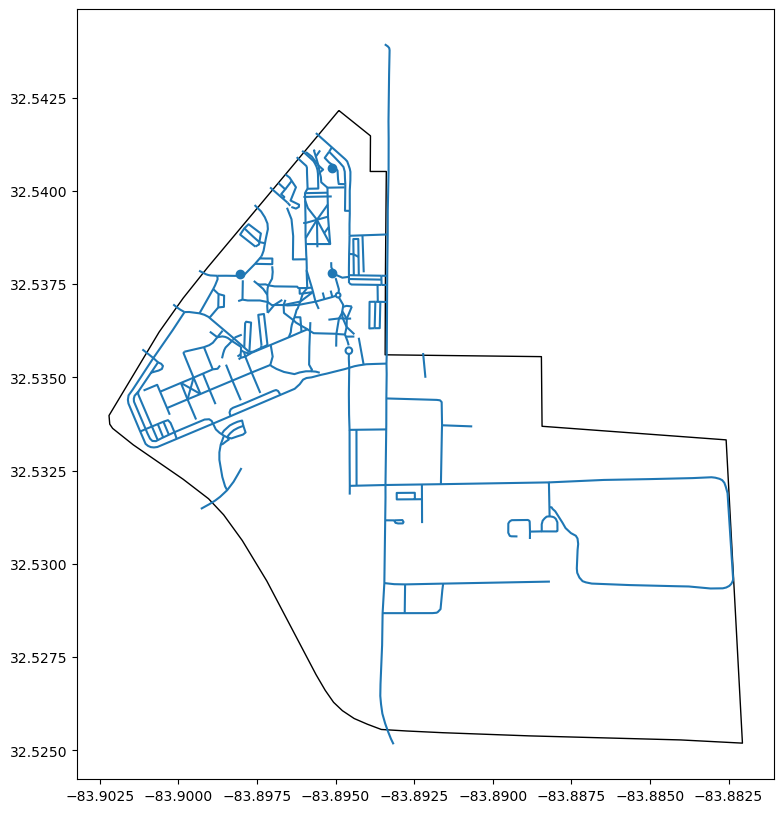

In [19]:
# Plot roads and boundary together
fig, ax = plt.subplots(figsize=(10,10))
roads.plot(ax=ax)
main_campus.plot(ax=ax, color='None', edgecolor='black')

In [20]:
# Clip roads to campus boundary
roads_clipped = gpd.clip(
    roads,
    main_campus
)

roads_clipped

geometry  \
element_type osmid                                                           
way          9424964     LINESTRING (-83.89279 32.52945, -83.89280 32.5...   
             9425060     LINESTRING (-83.89350 32.52868, -83.89280 32.5...   
             9425797     LINESTRING (-83.88818 32.52953, -83.89158 32.5...   
             1378601432  LINESTRING (-83.88881 32.53087, -83.88882 32.5...   
             1378601433  LINESTRING (-83.88822 32.53219, -83.88646 32.5...   
...                                                                    ...   
             818481158   LINESTRING (-83.89700 32.54004, -83.89667 32.5...   
             818488269   LINESTRING (-83.89659 32.54045, -83.89646 32.5...   
             818488270   LINESTRING (-83.89682 32.54022, -83.89660 32.5...   
             818488271   LINESTRING (-83.89639 32.54027, -83.89660 32.5...   
             9424161     LINESTRING (-83.89618 32.54086, -83.89606 32.5...   

                         bus      highway          name public_transport  \
element_type osmid                                                         
way          9424964     NaN  residential  Jackson Lane              NaN   
             9425060     NaN  residential   Plant Drive              NaN   
             9425797     NaN  residential   Ellis Drive              NaN   
             1378601432  NaN      service           NaN              NaN   
             1378601433  NaN      service           NaN              NaN   
...                      ...          ...           ...              ...   
             818481158   NaN      service           NaN              NaN   
             818488269   NaN      footway           NaN              NaN   
             818488270   NaN      footway           NaN              NaN   
             818488271   NaN      footway           NaN              NaN   
             9424161     NaN      service           NaN              NaN   

                        access  \
element_type osmid               
way          9424964       NaN   
             9425060       NaN   
             9425797       NaN   
             1378601432    NaN   
             1378601433    NaN   
...                        ...   
             818481158     NaN   
             818488269     NaN   
             818488270     NaN   
             818488271     NaN   
             9424161       NaN   

                                                                     nodes  \
element_type osmid                                                           
way          9424964                                  [71890819, 71890822]   
             9425060     [71893376, 71890822, 71893377, 71893379, 71893...   
             9425797     [71907089, 71893390, 71890819, 71907092, 71900...   
             1378601432                         [12765673699, 12765710712]   
             1378601433  [12765710713, 12765710714, 12765710715, 127657...   
...                                                                    ...   
             818481158                [7643723542, 7643783047, 7643723543]   
             818488269   [7643783035, 7643783036, 7643783048, 764378303...   
             818488270   [7643783043, 7643783044, 7643783045, 764378304...   
             818488271                            [7643783048, 7643783044]   
             9424161     [71882237, 71882236, 71882233, 6778464828, 677...   

                        oneway  surface tiger:cfcc  ... tiger:name_type  \
element_type osmid                                  ...                   
way          9424964       NaN      NaN        A41  ...              Ln   
             9425060       NaN      NaN        A41  ...              Dr   
             9425797       NaN      NaN        A41  ...              Dr   
             1378601432    NaN    paved        NaN  ...             NaN   
             1378601433    NaN  unpaved        NaN  ...             NaN   
...                        ...      ...        ...  ...             ...   
    

<Axes: >

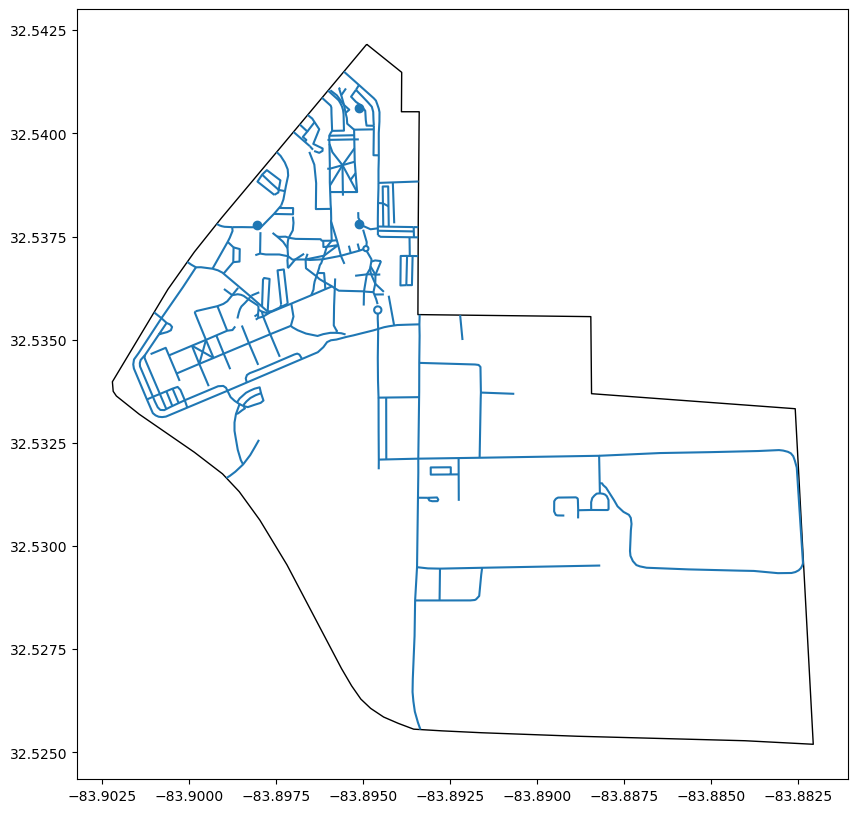

In [21]:
# Plot clipped roads and boundary together
fig, ax = plt.subplots(figsize=(10,10))
roads_clipped.plot(ax=ax)
main_campus.plot(ax=ax, color='None', edgecolor='black')

In [22]:
# Get water
water = osm.features_from_polygon(polygon,
                                      tags={"natural":"water",
                                            "waterway": True,
                                            "water":True})
water

nodes  \
element_type osmid                                                           
way          34443799    [396379364, 396379365, 396379367, 396379368, 3...   
             34447805    [396604972, 396604977, 396604980, 396604983, 3...   
             34447806    [396605056, 396605059, 396605064, 396605073, 3...   
             34456272    [396379423, 397015987, 397015990, 397015992, 3...   
             34457044    [397093488, 397093490, 397093493, 397093496, 3...   
             34484031    [398329976, 398329978, 398329980, 398329982, 3...   
             1018990021  [399969390, 399969391, 399969393, 399969395, 3...   
             1265392047  [397093914, 397093916, 397093918, 397093919, 3...   

                        NHD:ComID NHD:FCode    NHD:FType NHD:RESOLUTION  \
element_type osmid                                                        
way          34443799    80194731     46003  StreamRiver           High   
             34447805    80212847     39010          NaN           High   
             34447806    80212859     39010          NaN           High   
             34456272    80194729     46003  StreamRiver           High   
             34457044    80212835     39010          NaN           High   
             34484031    80212875     39010          NaN           High   
             1018990021       NaN       NaN          NaN            NaN   
             1265392047       NaN       NaN          NaN            NaN   

                          NHD:ReachCode NHD:way_id attribution  \
element_type osmid                                               
way          34443799     3070104004378   80194731         NHD   
             34447805    03070104007882        NaN         NaN   
             34447806    03070104007886        NaN         NaN   
             34456272     3070104004378   80194729         NHD   
             34457044    03070104007881        NaN         NaN   
             34484031    03070104007896        NaN         NaN   
             1018990021             NaN        NaN         NaN   
             1265392047             NaN        NaN         NaN   

                                                 source waterway  \
element_type osmid                                                 
way          34443799    NHD_import_v0.3_20090424145328   stream   
             34447805                               NHD      NaN   
             34447806                               NHD      NaN   
             34456272    NHD_import_v0.3_20090424145328   stream   
             34457044                               NHD      NaN   
             34484031                               NHD      NaN   
             1018990021                             NaN   stream   
             1265392047                             NaN      dam   

                                                                  geometry  \
element_type osmid                                                           
way          34443799    LINESTRING (-83.88979 32.52813, -83.88937 32.5...   
             34447805    POLYGON ((-83.89534 32.53155, -83.89535 32.531...   
             34447806    POLYGON ((-83.88832 32.52881, -83.88841 32.528...   
             34456272    LINESTRING (-83.88608 32.52593, -83.88568 32.5...   
             34457044    POLYGON ((-83.89576 32.52887, -83.89586 32.528...   
             34484031    POLYGON ((-83.88480 32.52591, -83.88490 32.525...   
             1018990021  LINESTRING (-83.89576 32.52887, -83.89579 32.5...   
             1265392047  LINESTRING (-83.89522 32.52870, -83.89527 32.5...   

                           NHD:Elevation   NHD:FDate NHD:FTYPE    ele natural  \
element_type osmid                                                              
way          34443799                NaN         NaN       NaN    NaN     NaN   
             34447805    150.30000000000  2003/04/14  LakePond  150.3   water   
             34447806    145.70000000000  2003/04/14  LakePond  145.7   water   
         

<Axes: >

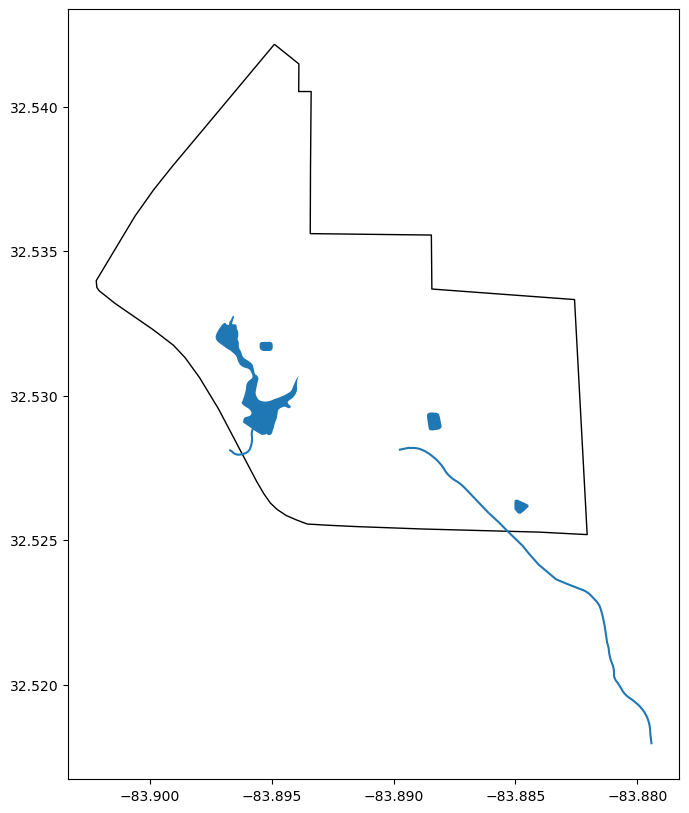

In [24]:
# Plot water and boundary together
fig, ax = plt.subplots(figsize=(10,10))
water.plot(ax=ax)
main_campus.plot(ax=ax, color='None', edgecolor='black')

In [26]:
# Clip water lines to campus boundary
water_clipped = gpd.clip(
    water,
    main_campus
)

water_clipped

nodes  \
element_type osmid                                                           
way          34456272    [396379423, 397015987, 397015990, 397015992, 3...   
             34484031    [398329976, 398329978, 398329980, 398329982, 3...   
             34443799    [396379364, 396379365, 396379367, 396379368, 3...   
             1018990021  [399969390, 399969391, 399969393, 399969395, 3...   
             1265392047  [397093914, 397093916, 397093918, 397093919, 3...   
             34447806    [396605056, 396605059, 396605064, 396605073, 3...   
             34457044    [397093488, 397093490, 397093493, 397093496, 3...   
             34447805    [396604972, 396604977, 396604980, 396604983, 3...   

                        NHD:ComID NHD:FCode    NHD:FType NHD:RESOLUTION  \
element_type osmid                                                        
way          34456272    80194729     46003  StreamRiver           High   
             34484031    80212875     39010          NaN           High   
             34443799    80194731     46003  StreamRiver           High   
             1018990021       NaN       NaN          NaN            NaN   
             1265392047       NaN       NaN          NaN            NaN   
             34447806    80212859     39010          NaN           High   
             34457044    80212835     39010          NaN           High   
             34447805    80212847     39010          NaN           High   

                          NHD:ReachCode NHD:way_id attribution  \
element_type osmid                                               
way          34456272     3070104004378   80194729         NHD   
             34484031    03070104007896        NaN         NaN   
             34443799     3070104004378   80194731         NHD   
             1018990021             NaN        NaN         NaN   
             1265392047             NaN        NaN         NaN   
             34447806    03070104007886        NaN         NaN   
             34457044    03070104007881        NaN         NaN   
             34447805    03070104007882        NaN         NaN   

                                                 source waterway  \
element_type osmid                                                 
way          34456272    NHD_import_v0.3_20090424145328   stream   
             34484031                               NHD      NaN   
             34443799    NHD_import_v0.3_20090424145328   stream   
             1018990021                             NaN   stream   
             1265392047                             NaN      dam   
             34447806                               NHD      NaN   
             34457044                               NHD      NaN   
             34447805                               NHD      NaN   

                                                                  geometry  \
element_type osmid                                                           
way          34456272    LINESTRING (-83.88608 32.52593, -83.88568 32.5...   
             34484031    POLYGON ((-83.88490 32.52593, -83.88504 32.526...   
             34443799    LINESTRING (-83.88979 32.52813, -83.88937 32.5...   
             1018990021  LINESTRING (-83.89576 32.52887, -83.89579 32.5...   
             1265392047  LINESTRING (-83.89522 32.52870, -83.89527 32.5...   
             34447806    POLYGON ((-83.88841 32.52880, -83.88848 32.528...   
             34457044    POLYGON ((-83.89586 32.52893, -83.89609 32.529...   
             34447805    POLYGON ((-83.89535 32.53155, -83.89539 32.531...   

                           NHD:Elevation   NHD:FDate NHD:FTYPE    ele natural  \
element_type osmid                                                              
way          34456272                NaN         NaN       NaN    NaN     NaN   
             34484031    140.80000000000  2003/04/14  LakePond  140.8   water   
             34443799                NaN         NaN       NaN    NaN     NaN   
         

<Axes: >

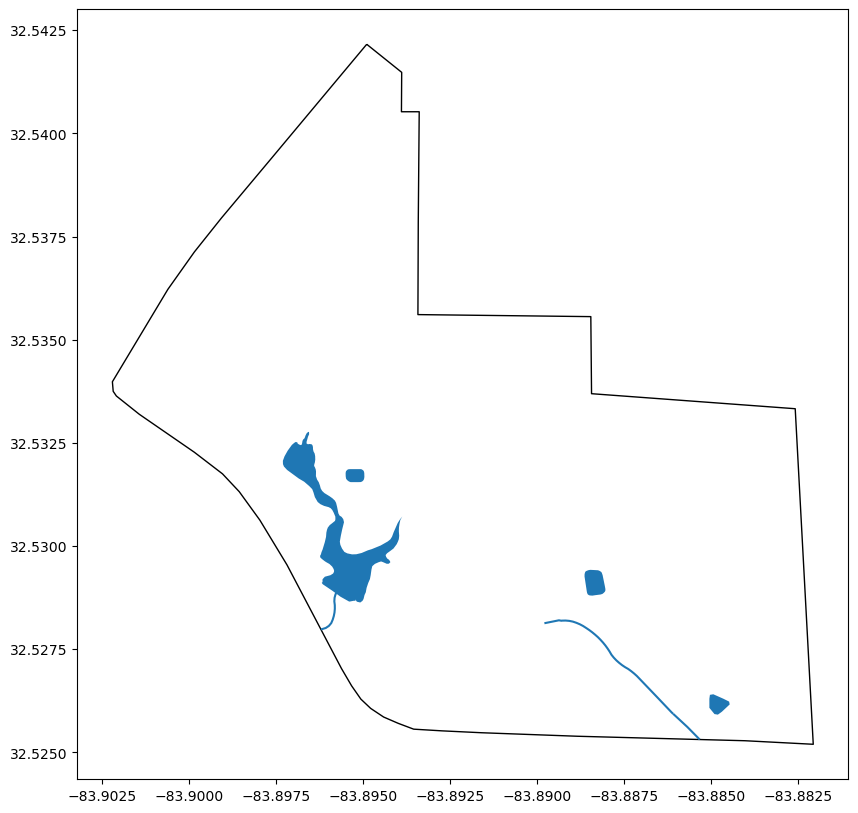

In [28]:
# Plot water and boundary together
fig, ax = plt.subplots(figsize=(10,10))
water_clipped.plot(ax=ax)
main_campus.plot(ax=ax, color='none', edgecolor='black')

In [29]:
# Splitting water into lines and polygons for easier plotting
water_polygons = water_clipped[
    water_clipped.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"])]

water_polygons


water_lines = water_clipped[
    water_clipped.geometry.geom_type.isin(
        ["LineString", "MultiLineString"])]

water_lines

nodes  \
element_type osmid                                                           
way          34456272    [396379423, 397015987, 397015990, 397015992, 3...   
             34443799    [396379364, 396379365, 396379367, 396379368, 3...   
             1018990021  [399969390, 399969391, 399969393, 399969395, 3...   
             1265392047  [397093914, 397093916, 397093918, 397093919, 3...   

                        NHD:ComID NHD:FCode    NHD:FType NHD:RESOLUTION  \
element_type osmid                                                        
way          34456272    80194729     46003  StreamRiver           High   
             34443799    80194731     46003  StreamRiver           High   
             1018990021       NaN       NaN          NaN            NaN   
             1265392047       NaN       NaN          NaN            NaN   

                         NHD:ReachCode NHD:way_id attribution  \
element_type osmid                                              
way          34456272    3070104004378   80194729         NHD   
             34443799    3070104004378   80194731         NHD   
             1018990021            NaN        NaN         NaN   
             1265392047            NaN        NaN         NaN   

                                                 source waterway  \
element_type osmid                                                 
way          34456272    NHD_import_v0.3_20090424145328   stream   
             34443799    NHD_import_v0.3_20090424145328   stream   
             1018990021                             NaN   stream   
             1265392047                             NaN      dam   

                                                                  geometry  \
element_type osmid                                                           
way          34456272    LINESTRING (-83.88608 32.52593, -83.88568 32.5...   
             34443799    LINESTRING (-83.88979 32.52813, -83.88937 32.5...   
             1018990021  LINESTRING (-83.89576 32.52887, -83.89579 32.5...   
             1265392047  LINESTRING (-83.89522 32.52870, -83.89527 32.5...   

                        NHD:Elevation NHD:FDate NHD:FTYPE  ele natural  \
element_type osmid                                                       
way          34456272             NaN       NaN       NaN  NaN     NaN   
             34443799             NaN       NaN       NaN  NaN     NaN   
             1018990021           NaN       NaN       NaN  NaN     NaN   
             1265392047           NaN       NaN       NaN  NaN     NaN   

                                                       name ref:US:NID  
element_type osmid                                                      
way          34456272                                   NaN        NaN  
             34443799                                   NaN        NaN  
             1018990021                                 NaN        NaN  
             1265392047  Fort Valley State College Lake Dam    GA04962

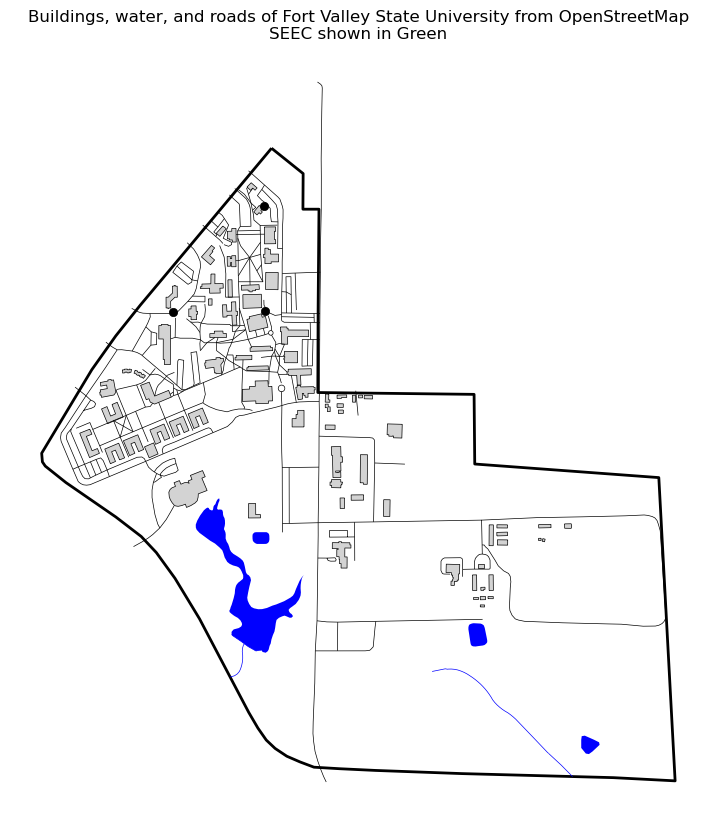

In [ ]:
# Plot all layers together on a single axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot East Campus boundary
main_campus.plot(
    ax=ax,
    color="None",
    linewidth=2
)

# Plot buildings
buildings.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

# Plot roads
roads.plot(
    ax=ax,
    color="black",
    linewidth=0.5)

# Plot water
water_clipped.plot(
    ax=ax,
    color="blue",
    linewidth=0.5)

# Plot SEEC
#seec.plot(ax=ax,
#          color='green',
 #         label='SEEC')

ax.set_title("Buildings, water, and roads of Fort Valley State University from OpenStreetMap")
ax.set_axis_off()

plt.show()